In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
print(dd.FORT_AVAIL)

True


In [2]:
def force(xp, yp, by, tau0, B, C):
    fdis = np.zeros_like(yp)
    for j, yj in enumerate(yp):
        hh = 0.
        for i, yi in enumerate(yp):
            if i==j:
                continue
            hh += B/(yj - yi)
        for i, xi in enumerate(xp-gbdd.Dgp*0.5):
            hr = (yj**2 + xi**2)
            hh += by[i]*yj*(yj**2 - xi**2)/hr**2
        fdis[j] = (C*hh - tau0)*B
    return fdis
        

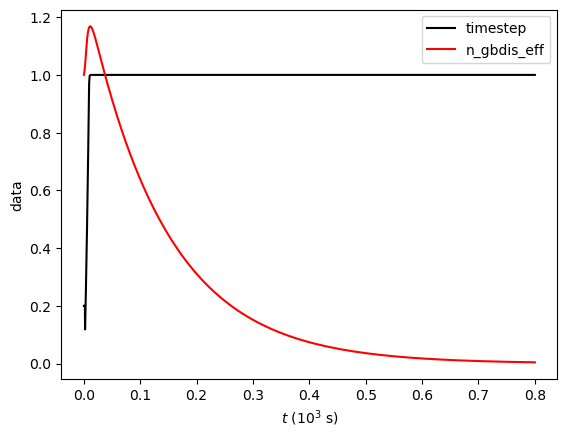

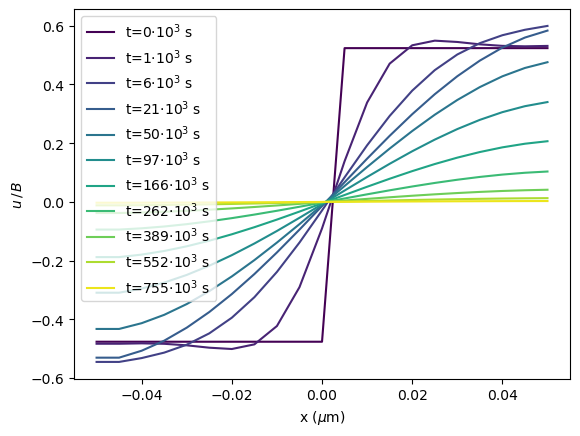

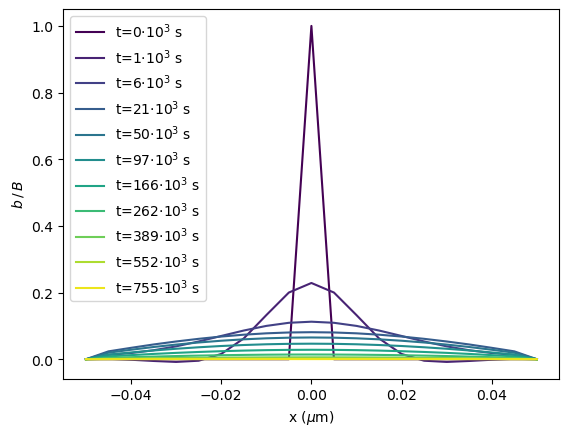

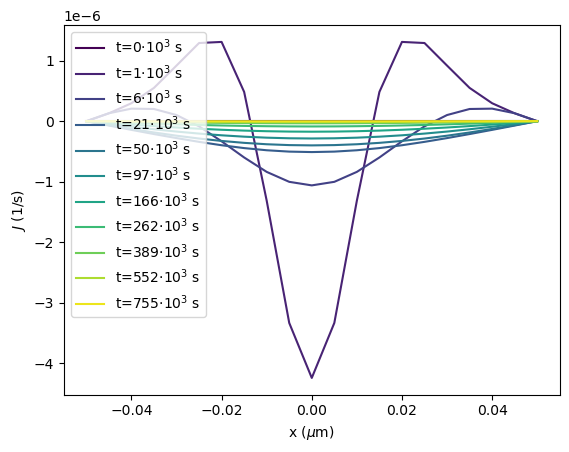

In [21]:
gbdd = dd.GB_dislocations(from_file="../examples/gbdd/Res-GB1/gb1_L1_N21_T900_dt5.h5")
gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
#gbdd.plot_time_series("plastic_slip")
#gbdd.plot_time_series("plast_slip_rate")
#gbdd.plot_time_series("psr_av")
gbdd.plot_field('displacement')
gbdd.plot_field('bfield')  # , file="T900_Lgb10_short.pdf")
gbdd.plot_field('flux')
#gbdd.plot_pile_up()
                          

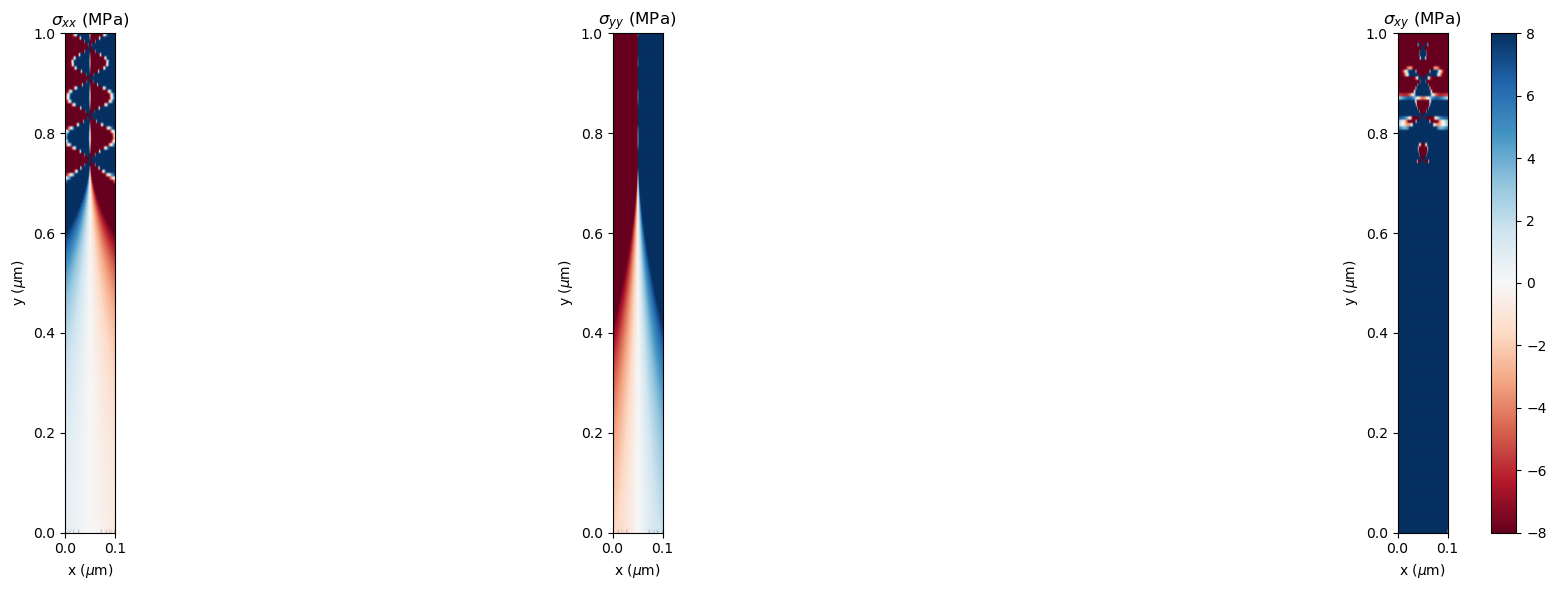

[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  0.00000000e+00 -9.49369013e-05 -1.30363105e-04 -1.43560660e-04
 -1.44693147e-04 -1.38595023e-04 -1.28125886e-04 -1.15167245e-04
 -1.01023148e-04 -8.66158789e-05 -7.25966503e-05 -5.94161501e-05
 -4.73740716e-05 -3.66565597e-05 -2.73659938e-05 -1.95453696e-05
 -1.31984602e-05 -8.30637915e-06 -4.84087615e-06 -2.77454941e-06
 -2.08807991e-06 -2.77454941e-06 -4.84087615e-06 -8.30637915e-06
 -1.31984602e-05 -1.95453696e-05 -2.73659938e-05 -3.66565597e-05
 -4.73740716e-05 -5.94161501e-05 -7.25966503e-05 -8.66158789e-05
 -1.01023148e-04 -1.15167245e-04 -1.28125886e-04 -1.38595023e-04
 -1.44693147e-04 -1.43560660e-04 -1.30363105e-04 -9.49369013e-05
  0.00000000e+00]
[0.7483727  0.83729431 0.91224121 0.97623449]
[-0.05109334 -0.0433133  -0.0351143  -0.02048703]
[-0.05109334 -0.0433133  -0.0351143  -0.02048703]
Rel. error in leading dislocation: -2.9692726055685625e-10
Average rel. error in pile-up: 3.835719519784675e-10


In [13]:
it = 10
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
gbf = gbdd.pu_dis['force'][it, ind]

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
dsl.plot_stress(show_arrows=False)
tau0 = gbdd.tau0
fpk = dsl.calc_force(tau0=-tau0)
#fdis = force(xp[npu:], yp[:npu], by[npu:]*gbdd.B, tau0, gbdd.B, C/gbdd.B)
print(by)
print(yp[:npu])
print(fpk[1, :])
print(gbf)
#print(fdis)
print(f"Rel. error in leading dislocation: {gbf[0]/fpk[1, 0]-1}")
print(f"Average rel. error in pile-up: {np.sum(np.abs(gbf[:npu]/fpk[1, :npu]-1))/npu}")

In [6]:
gbdd.nout

np.int64(1000)

In [ ]:
N = 100
res = []
for i in range(N):
    xp = np.random.rand(2)*5
    yp = np.random.rand(2)*5
    sp = np.random.rand(1)[0]*np.pi*.5
    df = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=5, LY=5,
                          bc="fixed")
    dp = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=50000, LY=50000,
                          bc="pbc")
    res.append(df.calc_force(tau0=0) / dp.calc_force(tau0=0) - 1)
    #print(dp.xpos, dp.ypos)
    #print(dp.bx, dp.by)
    #print(res[i])
print(np.max(np.abs(res)))
